# K07_01 – k-NN Two Moons: Skalierung und Wahl von k (Dozent)

## Lernziele
- k-NN auf einem **nichtlinear trennbaren** Datensatz anwenden
- den Unterschied **mit/ohne Skalierung** analysieren
- den Einfluss von `k` systematisch untersuchen
- `weights="uniform"` und `weights="distance"` vergleichen
- Entscheidungsgrenzen interpretieren

## Didaktischer Fokus

Dieses Notebook ist das **Kernnotebook** des k-NN-Kapitels.

Es zeigt besonders gut:
- warum k-NN flexible Entscheidungsgrenzen bilden kann
- warum Skalierung bei distanzbasierten Verfahren so wichtig ist
- wie stark der Hyperparameter `k` das Verhalten des Modells beeinflusst

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## 1. Datensatz erzeugen

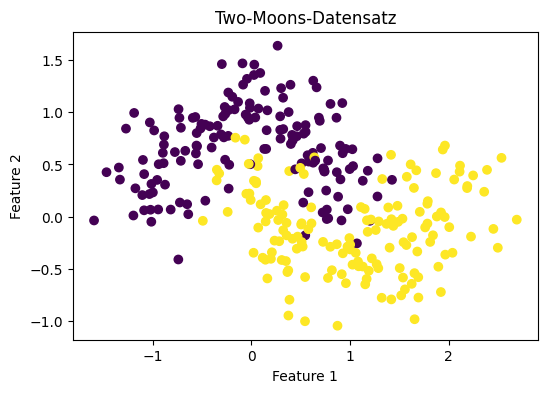

In [ ]:
X, y = make_moons(n_samples=300, noise=0.25, random_state=42)

plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Two-Moons-Datensatz")
plt.show()

## 2. Trainings- und Testdaten

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Trainingsdaten:", X_train.shape)
print("Testdaten:", X_test.shape)

Trainingsdaten: (210, 2)
Testdaten: (90, 2)


## 3. Vergleich: mit und ohne Skalierung

In [ ]:
knn_raw = KNeighborsClassifier(n_neighbors=5)
knn_raw.fit(X_train, y_train)
acc_raw = knn_raw.score(X_test, y_test)

knn_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("knn", KNeighborsClassifier(n_neighbors=5))
])
knn_pipe.fit(X_train, y_train)
acc_scaled = knn_pipe.score(X_test, y_test)

pd.DataFrame({
    "Variante": ["ohne Skalierung", "mit Skalierung"],
    "Accuracy": [acc_raw, acc_scaled]
}).round(4)

,Variante,Accuracy
0,ohne Skalierung,0.9000
1,mit Skalierung,0.9111


## 4. Einfluss von `k`

In [ ]:
results_k = []
for k in [1, 3, 5, 7, 9, 11, 15, 21, 31]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    results_k.append({"k": k, "Accuracy": pipe.score(X_test, y_test)})

df_k = pd.DataFrame(results_k).round(4)
df_k

,k,Accuracy
0,1,0.8889
1,3,0.9222
2,5,0.9111
3,7,0.8778
4,9,0.9000
5,11,0.9000
6,15,0.9000
7,21,0.8889
8,31,0.8778


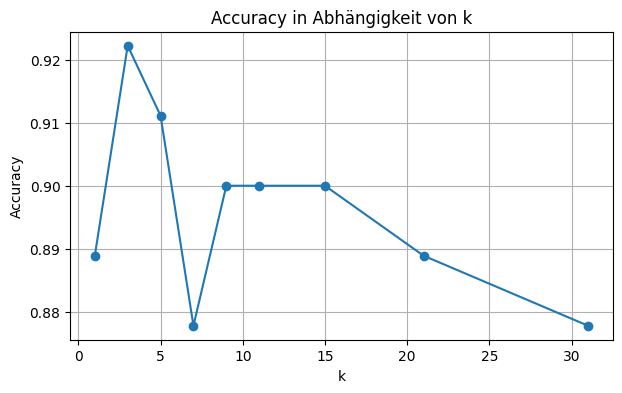

In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(df_k["k"], df_k["Accuracy"], marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy in Abhängigkeit von k")
plt.grid(True)
plt.show()

## 5. Vergleich von `weights="uniform"` und `weights="distance"`

In [ ]:
results_weights = []
for k in [3, 5, 9, 15]:
    for w in ["uniform", "distance"]:
        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("knn", KNeighborsClassifier(n_neighbors=k, weights=w))
        ])
        pipe.fit(X_train, y_train)
        results_weights.append({
            "k": k,
            "weights": w,
            "Accuracy": pipe.score(X_test, y_test)
        })

df_weights = pd.DataFrame(results_weights).round(4)
df_weights

,k,weights,Accuracy
0,3,uniform,0.9222
1,3,distance,0.9333
2,5,uniform,0.9111
3,5,distance,0.9222
4,9,uniform,0.9000
5,9,distance,0.9111
6,15,uniform,0.9000
7,15,distance,0.9000


## 6. Entscheidungsgrenzen visualisieren

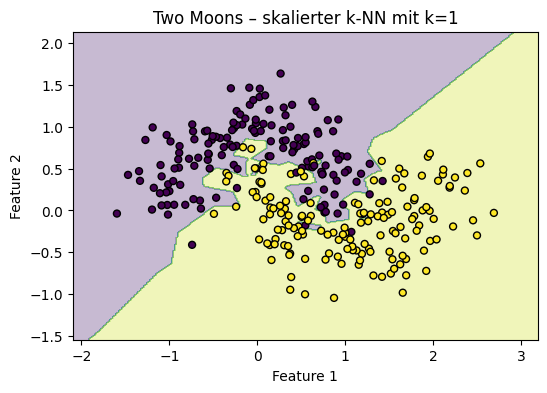

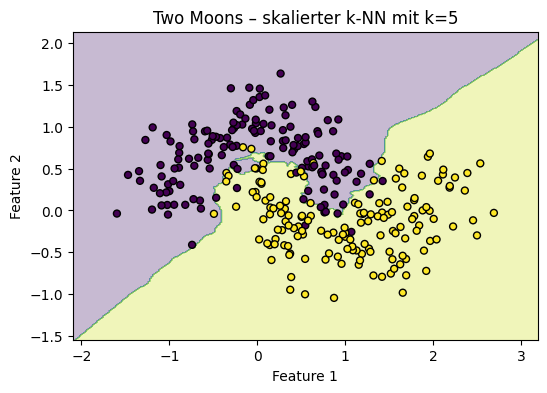

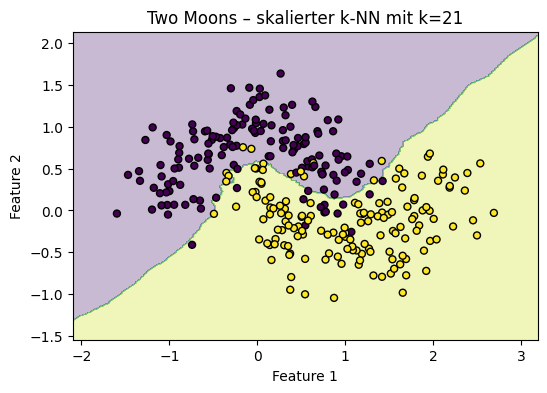

In [ ]:
def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid).reshape(xx.shape)

    plt.figure(figsize=(6, 4))
    plt.contourf(xx, yy, Z, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor="k", s=25)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

for k in [1, 5, 21]:
    pipe = Pipeline([
        ("scaler", StandardScaler()),
        ("knn", KNeighborsClassifier(n_neighbors=k))
    ])
    pipe.fit(X_train, y_train)
    plot_decision_boundary(pipe, X, y, f"Two Moons – skalierter k-NN mit k={k}")

## 7. Längere Analyseaufgabe

1. Vergleichen Sie k-NN **mit und ohne Skalierung** für `k=5`.  
   Erläutern Sie, warum die Unterschiede entstehen.

2. Untersuchen Sie die Accuracy für mehrere Werte von `k`.  
   Beschreiben Sie:
   - bei welchen `k`-Werten das Modell sehr lokal wirkt
   - bei welchen `k`-Werten das Modell zu grob wird

3. Vergleichen Sie `weights="uniform"` und `weights="distance"`.  
   Formulieren Sie:
   - wann gewichtete Nachbarn plausibel sind
   - ob die Unterschiede hier groß oder klein ausfallen

4. Interpretieren Sie die drei visualisierten Entscheidungsgrenzen (`k=1`, `k=5`, `k=21`).
   Gehen Sie ausdrücklich auf folgende Begriffe ein:
   - Flexibilität
   - Robustheit
   - Generalisierung

## 8. Fazit

- k-NN kann sehr flexible Entscheidungsgrenzen erzeugen.
- Skalierung ist bei distanzbasierten Verfahren oft unverzichtbar.
- Der Parameter `k` steuert die Balance zwischen lokaler Anpassung und Glättung.
- `weights="distance"` kann sinnvolle lokale Gewichtungen ermöglichen.

## 9. Musterlösung zur längeren Analyseaufgabe

Im Folgenden wird die Aufgabe systematisch gelöst.

**Ziel der Musterlösung**
- den Einfluss der Skalierung sichtbar machen
- die Wirkung verschiedener Werte von `k` fachlich interpretieren
- den Unterschied zwischen `weights="uniform"` und `weights="distance"` einordnen
- die Entscheidungsgrenzen bewusst im Hinblick auf Generalisierung lesen

In [ ]:
# Musterlösung Teil 1:
# Vergleich mit und ohne Skalierung für k=5

comparison_scaling = pd.DataFrame({
    "Variante": ["ohne Skalierung", "mit Skalierung"],
    "Accuracy": [acc_raw, acc_scaled]
}).round(4)

comparison_scaling

,Variante,Accuracy
0,ohne Skalierung,0.9000
1,mit Skalierung,0.9111


### Musterinterpretation zu Teil 1

Typischerweise ist das skalierte Modell mindestens genauso gut oder besser als das unskalierte Modell.

**Begründung:**  
k-NN basiert vollständig auf Distanzen. Ohne Skalierung können einzelne Merkmale die Distanzberechnung übermäßig dominieren.  
Die Skalierung sorgt dafür, dass beide Merkmale vergleichbarer in die Nachbarschaftsentscheidung eingehen.

In [ ]:
# Musterlösung Teil 2:
# Beste Werte für k bestimmen

df_k_sorted = df_k.sort_values(["Accuracy", "k"], ascending=[False, True]).reset_index(drop=True)
df_k_sorted.head(10)

,k,Accuracy
0,3,0.9222
1,5,0.9111
2,9,0.9000
3,11,0.9000
4,15,0.9000
5,1,0.8889
6,21,0.8889
7,7,0.8778
8,31,0.8778


In [ ]:
best_k_row = df_k_sorted.loc[0]
print("Bestes k:", int(best_k_row["k"]))
print("Beste Accuracy:", float(best_k_row["Accuracy"]))

Bestes k: 3
Beste Accuracy: 0.9222


### Musterinterpretation zu Teil 2

Typischerweise gilt:

- **sehr kleine Werte von `k`** führen zu stark lokalen Entscheidungen
- **mittlere Werte von `k`** liefern oft die beste Balance
- **sehr große Werte von `k`** glätten die Entscheidungsgrenze stark und verlieren lokale Struktur

Didaktisch kann man das so formulieren:

- kleines `k` → eher **hohe Flexibilität**, aber auch **Rauschanfälligkeit**
- großes `k` → eher **Robustheit**, aber Gefahr von **Underfitting**

In [ ]:
# Musterlösung Teil 3:
# Vergleich uniform vs. distance

df_weights_sorted = df_weights.sort_values(["Accuracy", "k"], ascending=[False, True]).reset_index(drop=True)
df_weights_sorted

,k,weights,Accuracy
0,3,distance,0.9333
1,3,uniform,0.9222
2,5,distance,0.9222
3,5,uniform,0.9111
4,9,distance,0.9111
5,9,uniform,0.9000
6,15,uniform,0.9000
7,15,distance,0.9000


### Musterinterpretation zu Teil 3

`weights="distance"` ist dann besonders plausibel, wenn sehr nahe Nachbarn deutlich informativer sind als weiter entfernte Nachbarn.

Typische Beobachtung in diesem Notebook:
- die Unterschiede zwischen `uniform` und `distance` sind oft vorhanden, aber nicht immer dramatisch
- `distance` kann lokale Strukturen etwas besser berücksichtigen
- `uniform` ist konzeptionell einfacher und oft bereits erstaunlich stark

Wichtige Lehrbotschaft:
> Nicht jeder zusätzliche Freiheitsgrad führt automatisch zu einem großen Leistungssprung.

### Musterantwort zu Teil 4: Interpretation der Entscheidungsgrenzen

**k = 1**
- sehr flexible Grenze
- stark lokal
- reagiert empfindlich auf einzelne Punkte
- erhöhtes Overfitting-Risiko

**k = 5**
- oft gute Balance zwischen Flexibilität und Stabilität
- lokale Struktur bleibt sichtbar
- Entscheidungsgrenze wirkt plausibel für neue Daten

**k = 21**
- deutlich glattere Grenze
- robuster gegenüber einzelnen Ausreißern
- Gefahr, dass lokale Struktur zu stark geglättet wird

**Didaktische Verdichtung**
- kleines `k` → hohe Varianz
- großes `k` → höhere Glättung, mehr Bias
- mittleres `k` → oft beste Generalisierung

In [ ]:
# Kompakte Übersichtstabelle für die Nachbesprechung

summary = pd.DataFrame({
    "Aspekt": [
        "Skalierung",
        "Kleines k",
        "Mittleres k",
        "Großes k",
        "weights='distance'"
    ],
    "Didaktische Kernaussage": [
        "Bei k-NN meist methodisch wichtig",
        "Sehr lokal, oft varianzanfällig",
        "Oft gute Balance aus Flexibilität und Robustheit",
        "Stärker geglättet, Gefahr von Underfitting",
        "Nahe Nachbarn zählen stärker"
    ]
})

summary

,Aspekt,Didaktische Kernaussage
0,Skalierung,Bei k-NN meist methodisch wichtig
1,Kleines k,"Sehr lokal, oft varianzanfällig"
2,Mittleres k,Oft gute Balance aus Flexibilität und Robustheit
3,Großes k,"Stärker geglättet, Gefahr von Underfitting"
4,weights='distance',Nahe Nachbarn zählen stärker


## 10. Didaktische Hinweise für die Vorlesung

Dieses Notebook eignet sich sehr gut für die Live-Lehre, weil hier mehrere zentrale ML-Ideen gleichzeitig sichtbar werden:

1. **Vorverarbeitung beeinflusst das Modell direkt**  
   Bei k-NN ist Skalierung kein Nebenthema.

2. **Hyperparameter verändern die Modelllogik**  
   `k` verändert nicht nur eine Zahl, sondern das Verhalten des Verfahrens.

3. **Entscheidungsgrenzen sind interpretierbar**  
   Die Studierenden können direkt sehen, was „zu lokal“ oder „zu grob“ bedeutet.

Für die Besprechung empfehle ich besonders:
- `k=1`
- `k=5`
- `k=21`

Diese drei Werte machen die Veränderung sehr anschaulich sichtbar.